## FLIGHT BOOKINGS & TRAVEL DATA ANALYSIS

### General Information :

1. Number of Rows: 250
2. Number of Columns: 9

### Purpose: 

- Simulated dataset representing airline ticket bookings, useful for  data analysis, visualization and business insights in the aviation/travel industry.

### Value Distributions

1. Airlines: Randomly chosen among 6 international airlines.
2. Travel_Class: Balanced mix of Economy, Premium Economy, Business, and First.
3. Departure_City: Covers major global hubs (London, Mumbai, Dubai, New York, Singapore, Frankfurt, Delhi, Paris).
4. Payment_Method: Multiple payment modes included for diversity.

### Possible Use Cases

1. Exploratory Data Analysis (EDA): Ticket price trends, passenger age distribution, duration vs distance analysis.
2. Visualization: Compare average ticket prices by airline, travel class, or city.
3. Business Insights: Identify most common payment methods, popular routes, and preferred travel classes.

### Some possible questions to solve with this dataset:

1. Which airline has the highest average ticket price?
2. Is there a correlation between distance and ticket price?
3. What is the average passenger age for each travel class?
4. Which departure city shows the longest average flight duration?
5. Which payment method is most popular for business-class travelers?
6. Do older passengers prefer certain airlines or payment methods?

### Exploratory Data Analysis

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r'C:\Users\Srikant Verma\Desktop\Data Analytics\Power BI\Colortech Training\Flight Bookings & Travel Data Analysis\Project Files\Flight Booking & Durations.csv')

In [6]:
df.head()

,Booking_ID,Ticket_Price,Distance_km,Flight_Duration_hr,Passenger_Age,Airline,Travel_Class,Departure_City,Payment_Method
0,FB1001,3015.91,12243.3,23.92,60,Q Airways,Business,Singapore,Credit Card
1,FB1002,416.23,1034.1,1.42,52,L Airlines,Economy,London,Cash
2,FB1003,2897.73,7842.7,12.66,59,E Airlines,Economy,Singapore,Cash
3,FB1004,4173.46,1987.1,2.22,38,B Airways,Business,Frankfurt,PayPal
4,FB1005,2500.49,14944.2,25.75,65,E Airlines,Business,London,Cash


In [7]:
df.tail()

,Booking_ID,Ticket_Price,Distance_km,Flight_Duration_hr,Passenger_Age,Airline,Travel_Class,Departure_City,Payment_Method
245,FB1246,766.65,6273.8,9.63,24,Air I,Business,New York,Credit Card
246,FB1247,3278.84,10887.8,15.77,37,L Airlines,Business,Singapore,PayPal
247,FB1248,678.12,14396.2,28.32,30,B Airways,Economy,Dubai,Cash
248,FB1249,4878.30,8615.7,13.52,65,Air I,First,Paris,Cash
249,FB1250,3165.45,7601.5,10.98,54,E Airlines,Premium Economy,Frankfurt,Credit Card


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Booking_ID          250 non-null    object 
 1   Ticket_Price        250 non-null    float64
 2   Distance_km         250 non-null    float64
 3   Flight_Duration_hr  250 non-null    float64
 4   Passenger_Age       250 non-null    int64  
 5   Airline             250 non-null    object 
 6   Travel_Class        250 non-null    object 
 7   Departure_City      250 non-null    object 
 8   Payment_Method      250 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 17.7+ KB


In [9]:
df.describe()

,Ticket_Price,Distance_km,Flight_Duration_hr,Passenger_Age
count,250.000000,250.000000,250.000000,250.000000
mean,2578.259040,7556.954000,11.041600,45.596000
std,1500.475213,4161.211576,6.394044,20.724643
min,113.350000,220.500000,0.260000,13.000000
25%,1203.885000,4211.775000,5.695000,28.000000
50%,2604.485000,7658.600000,11.220000,43.000000
75%,3986.327500,11369.950000,15.882500,62.000000
max,4985.360000,14944.200000,28.320000,80.000000


In [10]:
df.isnull().sum()

Booking_ID            0
Ticket_Price          0
Distance_km           0
Flight_Duration_hr    0
Passenger_Age         0
Airline               0
Travel_Class          0
Departure_City        0
Payment_Method        0
dtype: int64

### KPI Creation

#### Total Bookings

In [11]:
Total_Bookings = df['Booking_ID'].nunique()

print(Total_Bookings)

250


#### Total Ticket Price

In [12]:
Total_Ticket_Price = df['Ticket_Price'].sum()

print(Total_Ticket_Price)

644564.76


#### Average Passenger Age

In [13]:
Average_Passenger_Age = df['Passenger_Age'].mean().round(2)

print(Average_Passenger_Age)

45.6


#### Total Distance

In [14]:
Total_Distance = df['Distance_km'].sum()

print(Total_Distance)

1889238.5


#### Average Flight Duration

In [15]:
Average_Flight_Duration = df['Flight_Duration_hr'].mean().round(2)

print(Average_Flight_Duration)

11.04


#### Average Ticket Price

In [16]:
Average_Ticket_Price = df['Ticket_Price'].mean().round(2)

print(Average_Ticket_Price)

2578.26


#### Total Ticket Price By Airline

In [17]:
Total_Ticket_Price_By_Airline = df.groupby('Airline', as_index=False)['Ticket_Price'].sum().sort_values(by='Ticket_Price',ascending= False).reset_index(drop=True).rename(columns = {'Ticket_Price' : 'Total_Ticket_Price'})

print(Total_Ticket_Price_By_Airline)

      Airline  Total_Ticket_Price
0   B Airways           128586.36
1  S Airlines           113582.15
2  E Airlines           111509.66
3  L Airlines           104957.42
4       Air I            97848.00
5   Q Airways            88081.17


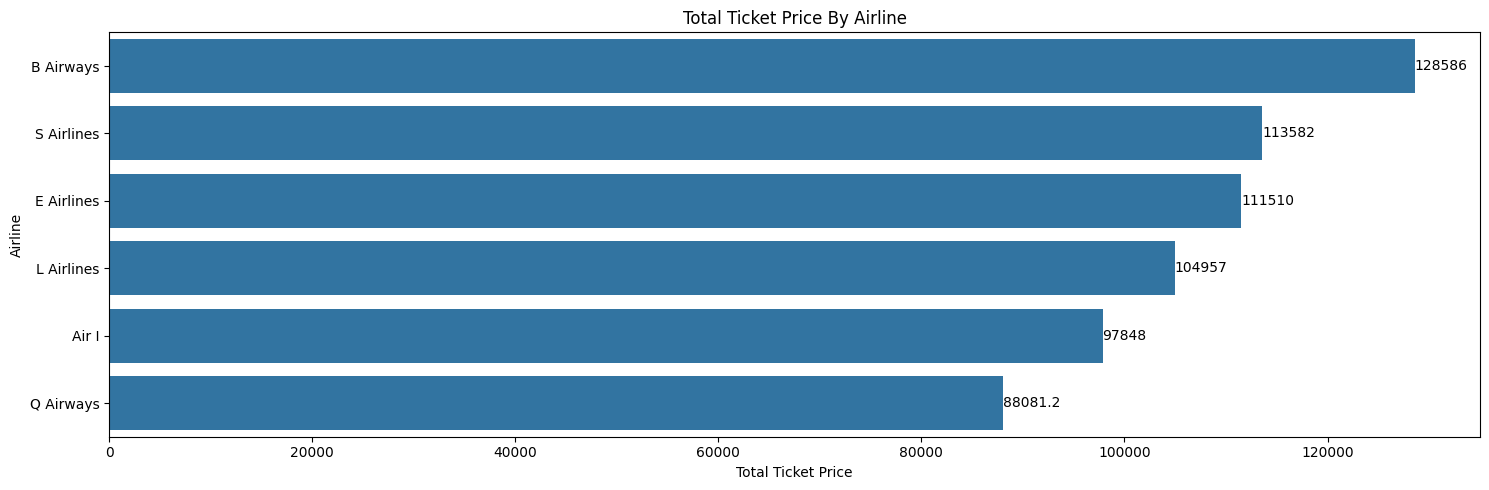

In [18]:
# Visualization

plt.figure(figsize = (15, 5))
ax = sns.barplot( data = Total_Ticket_Price_By_Airline , x = 'Total_Ticket_Price', y = 'Airline' )

for container in ax.containers :
    ax.bar_label(container)

plt.xlabel('Total Ticket Price')
plt.ylabel('Airline')
plt.title('Total Ticket Price By Airline')
plt.tight_layout()  
plt.show()

#### Total Ticket Price By Departure City

In [19]:
Total_Ticket_Price_By_Departure_City = df.groupby('Departure_City', as_index= False)['Ticket_Price'].sum().sort_values(by = 'Ticket_Price', ascending= False).reset_index(drop=True).rename(columns = {'Ticket_Price' : 'Total_Ticket_Price'})

print(Total_Ticket_Price_By_Departure_City)

  Departure_City  Total_Ticket_Price
0         Mumbai            98342.65
1         London            91389.28
2          Delhi            82615.46
3      Singapore            80822.51
4      Frankfurt            78098.85
5          Paris            76174.09
6          Dubai            72613.66
7       New York            64508.26


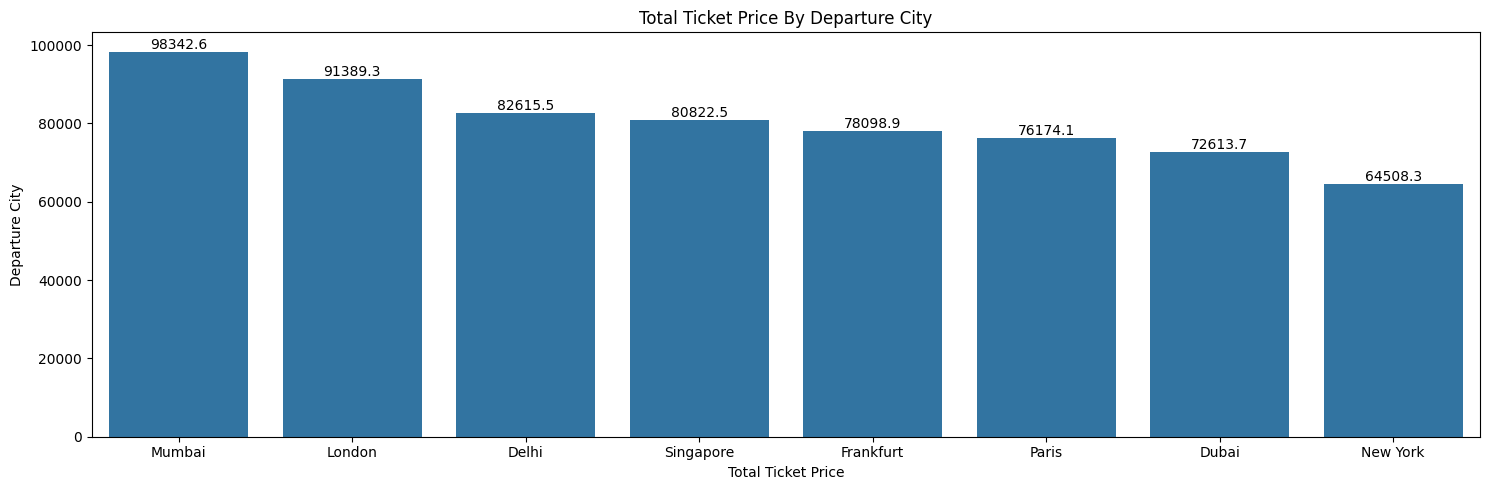

In [20]:
# Visualization

plt.figure(figsize= ( 15, 5))

ax = sns.barplot( x = 'Departure_City', y = 'Total_Ticket_Price', data = Total_Ticket_Price_By_Departure_City)

for i in ax.containers :
    ax.bar_label(i)

plt.title('Total Ticket Price By Departure City')
plt.xlabel('Total Ticket Price')
plt.ylabel('Departure City')
plt.tight_layout()
plt.show()

#### Total Bookings By Travel Class

In [21]:
Total_Bookings_By_Travel_Class = df.groupby('Travel_Class', as_index= False)['Booking_ID'].nunique().sort_values(by='Booking_ID', ascending= False).reset_index(drop=True).rename(columns = {'Booking_ID' : 'Total_Bookings'})

print(Total_Bookings_By_Travel_Class)

      Travel_Class  Total_Bookings
0  Premium Economy              69
1            First              63
2         Business              62
3          Economy              56


<Axes: ylabel='count'>

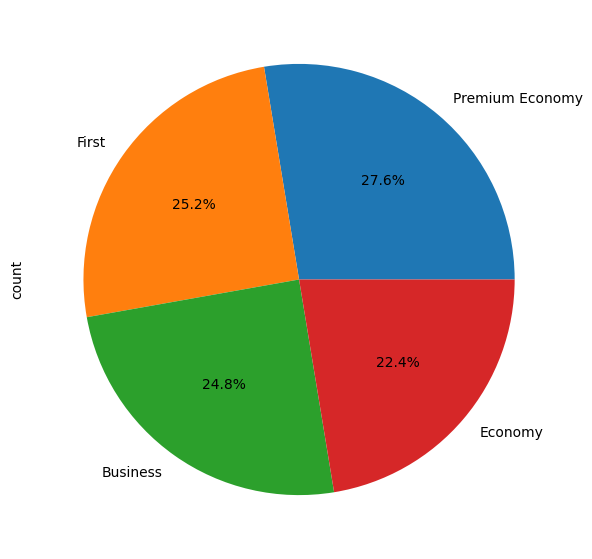

In [22]:
## Visualisation

plt.figure( figsize = ( 7,7 ))
df['Travel_Class'].value_counts().plot.pie(autopct = '%1.1f%%')

##### Total Ticket Price By Payment Method

In [23]:
Total_Ticket_Price_By_Payment_Method = df.groupby('Payment_Method', as_index= False)['Ticket_Price'].sum().sort_values(by= 'Ticket_Price', ascending= False).reset_index(drop=True).rename(columns = {'Ticket_Price' : 'Total_Ticket_Price'})

print(Total_Ticket_Price_By_Payment_Method)

  Payment_Method  Total_Ticket_Price
0    Credit Card           120917.30
1    Net Banking           120649.37
2           Cash           117776.17
3         PayPal           111431.98
4     Debit Card            99255.42
5            UPI            74534.52


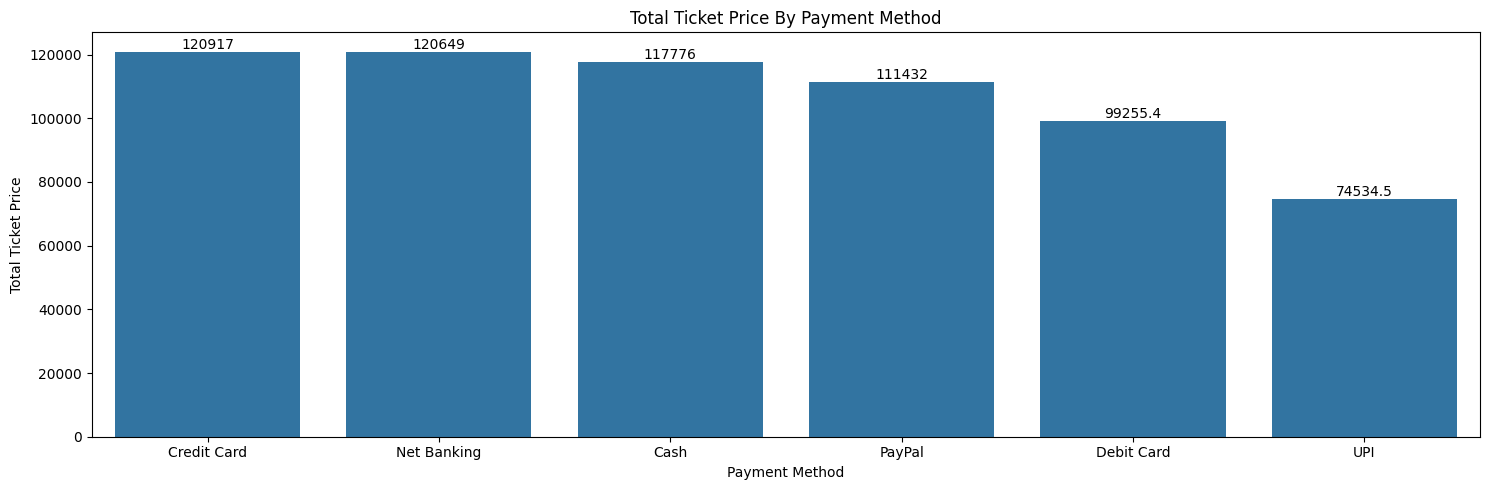

In [24]:
# Visualization 

plt.figure(figsize = ( 15, 5 ))

ax = sns.barplot( data = Total_Ticket_Price_By_Payment_Method, x = 'Payment_Method', y = 'Total_Ticket_Price' )

for i in ax.containers :
    ax.bar_label(i)

plt.title('Total Ticket Price By Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Ticket Price')
plt.tight_layout()
plt.show()

#### Total Bookings By Payment Method

In [25]:
Total_Bookings_By_Payment_Method = df.groupby('Payment_Method', as_index= False)['Booking_ID'].nunique().sort_values(by= 'Booking_ID', ascending= False).reset_index(drop=True).rename( columns = {'Booking_ID' : 'Total_Bookings'})

print(Total_Bookings_By_Payment_Method)

  Payment_Method  Total_Bookings
0    Credit Card              47
1           Cash              45
2    Net Banking              45
3         PayPal              44
4     Debit Card              38
5            UPI              31


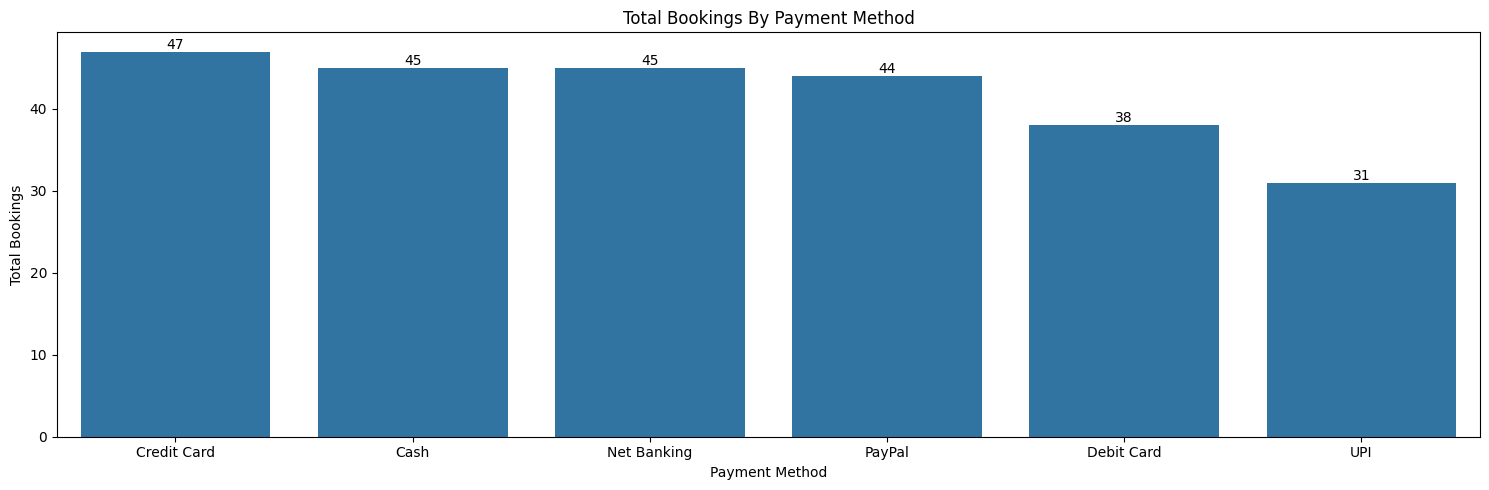

In [26]:
# Visualization 

plt.figure(figsize = ( 15, 5 ))

ax = sns.barplot( data = Total_Bookings_By_Payment_Method, x = 'Payment_Method', y = 'Total_Bookings' )

for i in ax.containers :
    ax.bar_label(i)

plt.title('Total Bookings By Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Bookings')
plt.tight_layout()
plt.show()

#### Total Ticket Price By Passenger Age

In [27]:
df['Passenger_Age'].describe()

count    250.000000
mean      45.596000
std       20.724643
min       13.000000
25%       28.000000
50%       43.000000
75%       62.000000
max       80.000000
Name: Passenger_Age, dtype: float64

In [28]:
## Creating Passenger Age Groups column to seggregate data into 5 age groups

bins = [ 0, 20, 40, 60, 80 ]  # age group bins
labels = [ '0-20', '21-40', '41-60', '61-80' ] # age group labels

df['Passenger_Age_Group'] = pd.cut(df['Passenger_Age'], bins = bins, labels = labels)
# pd.cut() --> this creates groups that is converts the numerical data into bins ( groups )

df['Passenger_Age_Group'] = pd.Categorical(df['Passenger_Age_Group'], categories=labels, ordered= False)
# pd.categorical() --> this controls order of categories or groups that helps in sorting 

Total_Ticket_Price_By_Passenger_Age = df.groupby('Passenger_Age_Group', as_index= False, observed = True)['Ticket_Price'].sum().sort_values(by= 'Ticket_Price',ascending= False).reset_index(drop = True).rename(columns = {'Ticket_Price' : 'Total_Ticket_Price'})
# observed = True --> this shows only those categories that have data inside it and skips the ones with no data
# observed = False --> this shows all the categories including the ones that have data and the ones that dont have.

print(Total_Ticket_Price_By_Passenger_Age)

  Passenger_Age_Group  Total_Ticket_Price
0               21-40           201088.78
1               61-80           183379.23
2               41-60           174459.19
3                0-20            85637.56


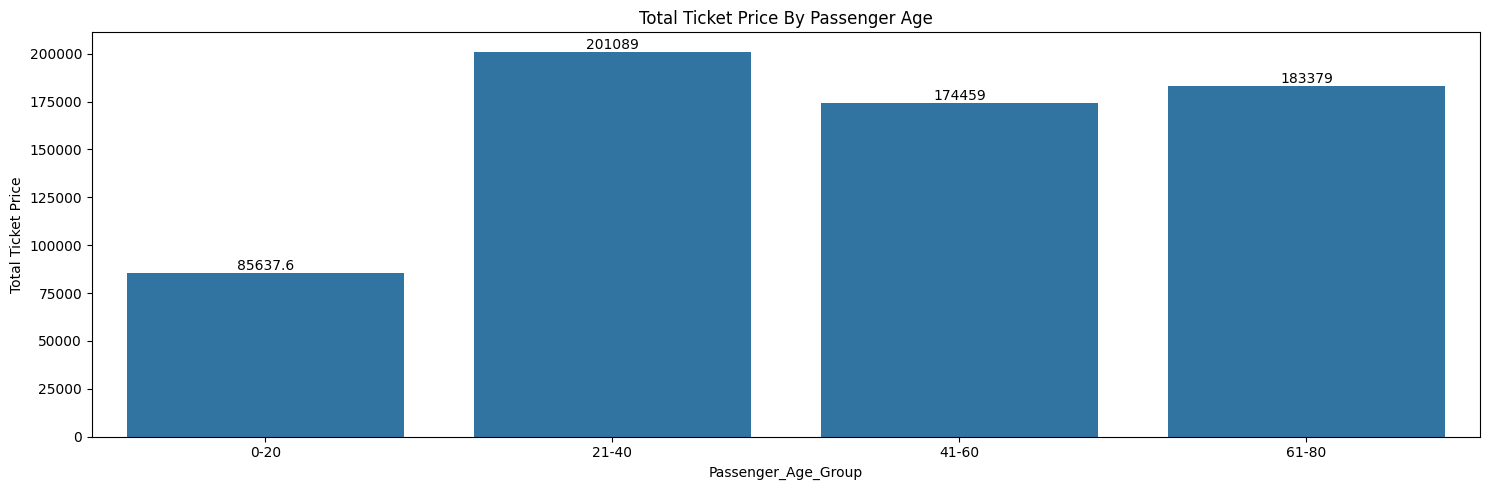

In [29]:
# Visualization 

plt.figure(figsize = ( 15, 5 ))

ax = sns.barplot( data = Total_Ticket_Price_By_Passenger_Age, x = 'Passenger_Age_Group', y = 'Total_Ticket_Price' )

for i in ax.containers :
    ax.bar_label(i)

plt.title('Total Ticket Price By Passenger Age')
plt.xlabel('Passenger_Age_Group')
plt.ylabel('Total Ticket Price')
plt.tight_layout()
plt.show()

##### Flight Duration Consistency

In [30]:
Variation_In_Flight_Duration = df['Flight_Duration_hr'].std(ddof = 0).round(2)
## .std(ddof = 0) --> this means standard deviation of whole population ; ddof = 1 --> sample population

print(Variation_In_Flight_Duration)

6.38


#### Total Flight Duration

In [31]:
Total_Flight_Duration = df['Flight_Duration_hr'].sum().round(2)

print(Total_Flight_Duration)

2760.4


#### Average Flight Duration By Airline

In [32]:
Average_Flight_Duration_By_Airline = df.groupby('Airline', as_index= False)['Flight_Duration_hr'].mean().sort_values(by='Flight_Duration_hr', ascending= False).reset_index(drop = True).round(2).rename(columns = {'Flight_Duration_hr' : 'Average_Flight_Duration'})

print(Average_Flight_Duration_By_Airline)

      Airline  Average_Flight_Duration
0       Air I                    12.99
1   Q Airways                    12.16
2  E Airlines                    12.02
3  L Airlines                    10.45
4   B Airways                     9.88
5  S Airlines                     9.43


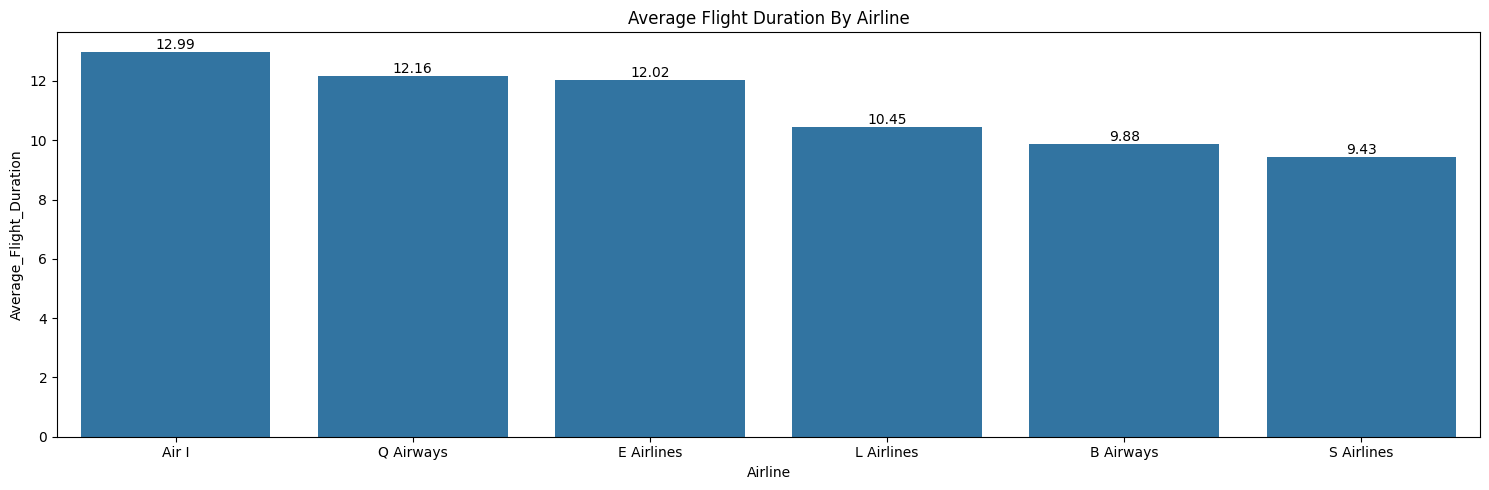

In [33]:
# Visualization 

plt.figure(figsize = ( 15, 5 ))

ax = sns.barplot( data = Average_Flight_Duration_By_Airline, x = 'Airline', y = 'Average_Flight_Duration' )

for i in ax.containers :
    ax.bar_label(i)

plt.title('Average Flight Duration By Airline')
plt.xlabel('Airline')
plt.ylabel('Average_Flight_Duration')
plt.tight_layout()
plt.show()

#### Average Flight Duration By Payment Method

In [34]:
Average_Flight_Duration_By_Payment_Method = df.groupby('Payment_Method', as_index= False)['Flight_Duration_hr'].mean().sort_values(by='Flight_Duration_hr', ascending= False).reset_index(drop = True).round(2).rename(columns = {'Flight_Duration_hr' : 'Average_Flight_Duration'})

print(Average_Flight_Duration_By_Payment_Method)

  Payment_Method  Average_Flight_Duration
0           Cash                    12.15
1    Credit Card                    11.41
2    Net Banking                    10.99
3     Debit Card                    10.94
4         PayPal                    10.84
5            UPI                     9.35


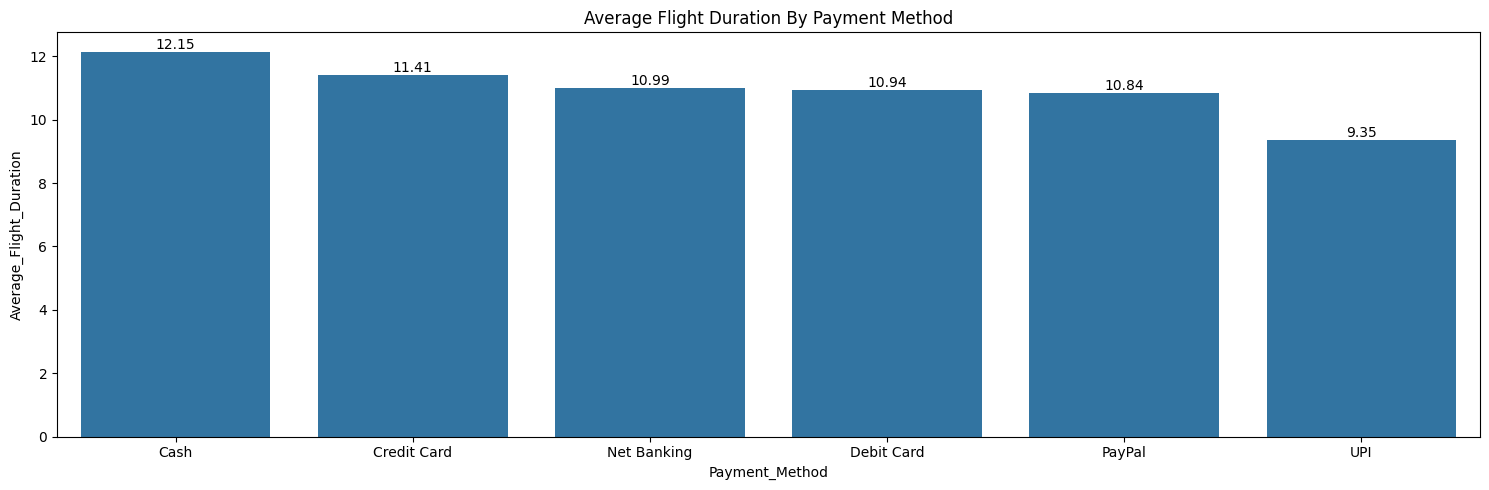

In [35]:
# Visualization 

plt.figure(figsize = ( 15, 5 ))

ax = sns.barplot( data = Average_Flight_Duration_By_Payment_Method, x = 'Payment_Method', y = 'Average_Flight_Duration' )

for i in ax.containers :
    ax.bar_label(i)

plt.title('Average Flight Duration By Payment Method')
plt.xlabel('Payment_Method')
plt.ylabel('Average_Flight_Duration')
plt.tight_layout()
plt.show()

#### Average Flight Duration By Passenger Age

In [36]:
Average_Flight_Duration_By_Passenger_Age_Group = df.groupby('Passenger_Age_Group', as_index= False, observed= True)['Flight_Duration_hr'].mean().sort_values(by= 'Flight_Duration_hr', ascending= False).reset_index(drop = True).round(2).rename(columns = {'Flight_Duration_hr' : 'Average_Flight_Duration'})

print(Average_Flight_Duration_By_Passenger_Age_Group)

  Passenger_Age_Group  Average_Flight_Duration
0                0-20                    13.81
1               41-60                    11.77
2               21-40                    10.70
3               61-80                     9.50


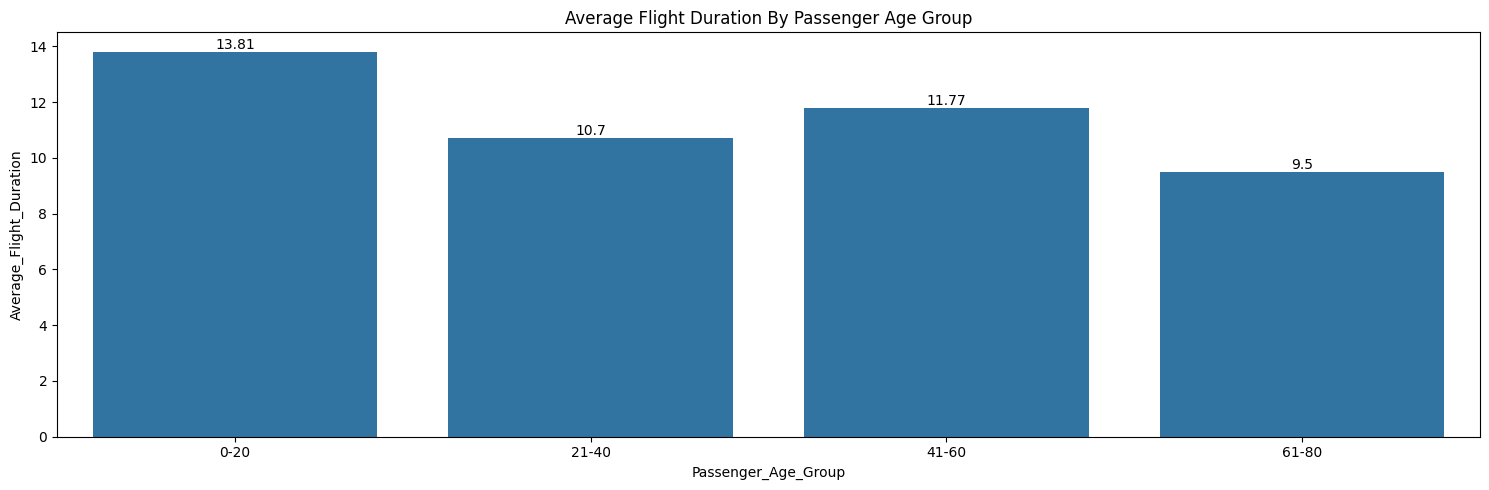

In [37]:
# Visualization 

plt.figure(figsize = ( 15, 5 ))

ax = sns.barplot( data = Average_Flight_Duration_By_Passenger_Age_Group, x = 'Passenger_Age_Group', y = 'Average_Flight_Duration' )

for i in ax.containers :
    ax.bar_label(i)

plt.title('Average Flight Duration By Passenger Age Group')
plt.xlabel('Passenger_Age_Group')
plt.ylabel('Average_Flight_Duration')
plt.tight_layout()
plt.show()

#### Flight Duration & Variation By City

In [38]:
Average_Flight_Duration_And_Variation_By_City = df.groupby( 'Departure_City', as_index = False).agg( Average_Flight_Duration = ( 'Flight_Duration_hr' , 'mean' ), Flight_Duration_Variation = ( 'Flight_Duration_hr', lambda x : x.std(ddof = 0))).sort_values( by = [ 'Flight_Duration_Variation', 'Average_Flight_Duration' ], ascending = [ False, False ] ).reset_index( drop = True ).round(2)

print(Average_Flight_Duration_And_Variation_By_City)    

  Departure_City  Average_Flight_Duration  Flight_Duration_Variation
0         London                    10.86                       6.93
1      Frankfurt                    10.30                       6.92
2      Singapore                    11.73                       6.54
3          Dubai                    12.08                       6.44
4       New York                     9.82                       6.19
5          Paris                    10.85                       6.05
6          Delhi                    11.50                       6.01
7         Mumbai                    11.15                       5.68


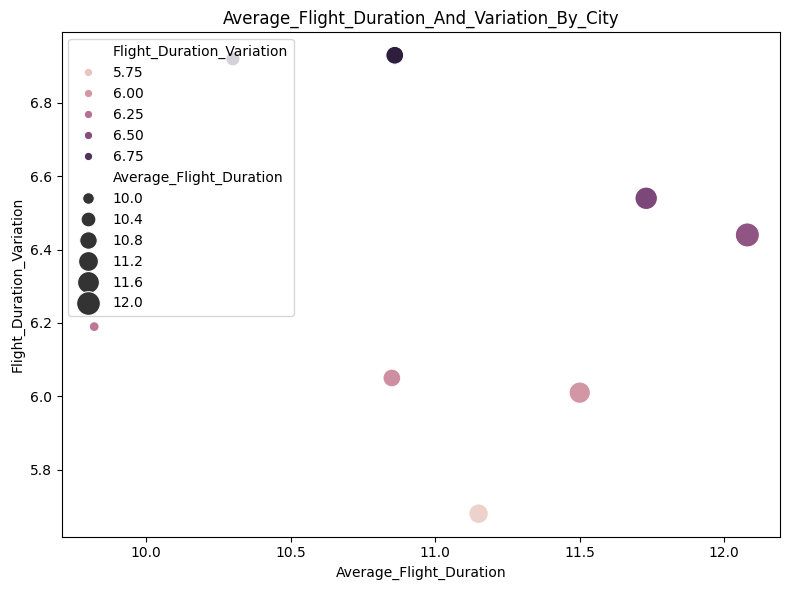

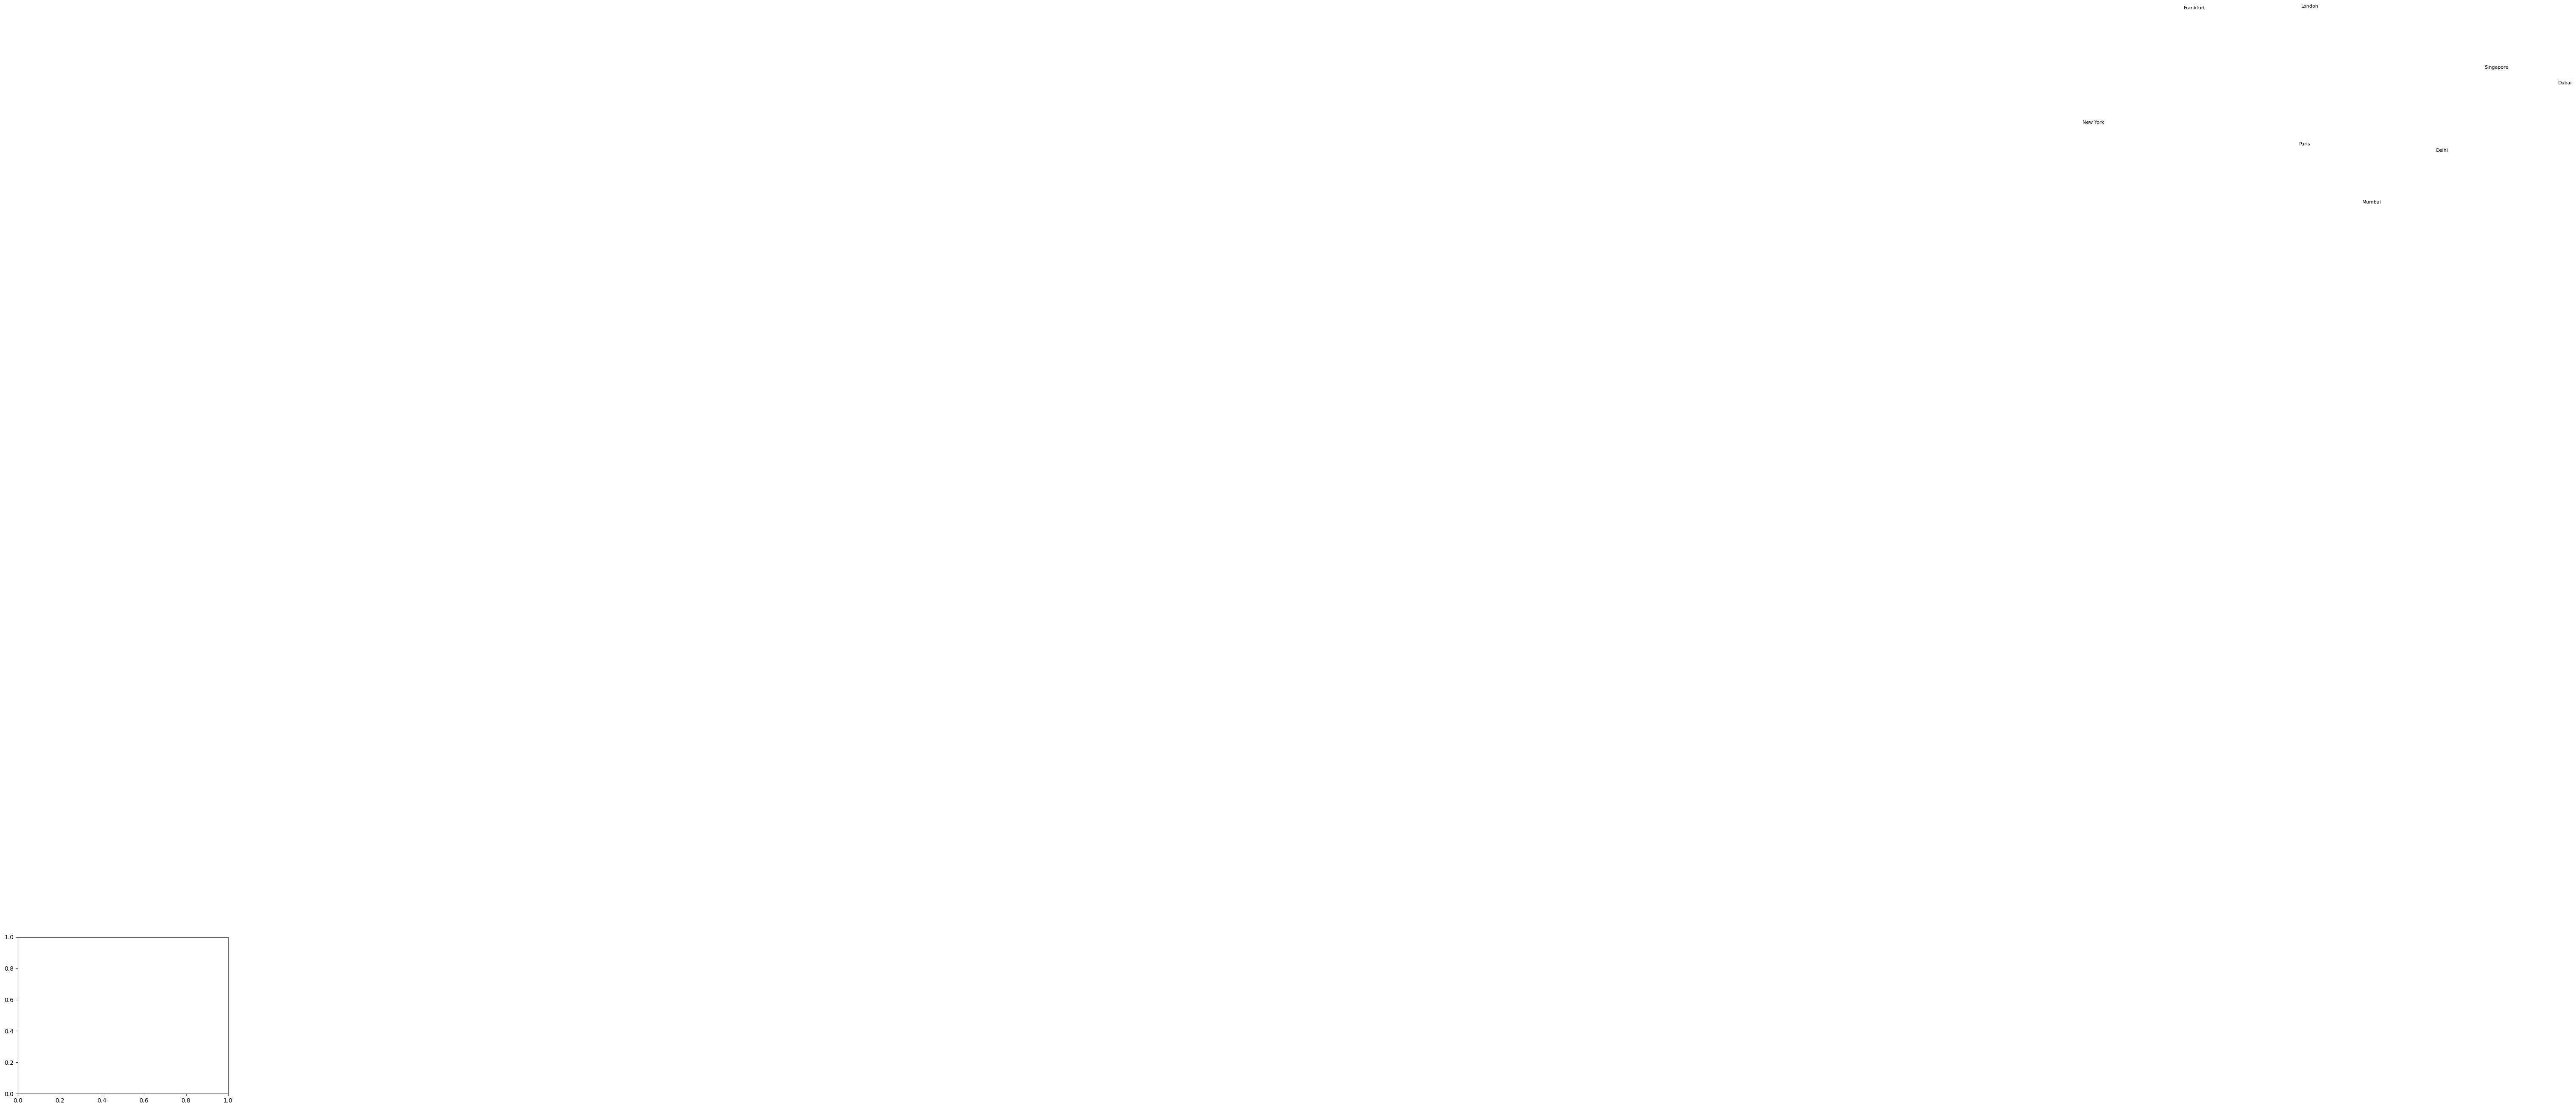

In [39]:
## Visualization

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=Average_Flight_Duration_And_Variation_By_City,
    x='Average_Flight_Duration',
    y='Flight_Duration_Variation',
    size='Average_Flight_Duration',
    sizes=(50, 300),
    hue='Flight_Duration_Variation'
)

plt.title('Average_Flight_Duration_And_Variation_By_City')
plt.xlabel('Average_Flight_Duration')
plt.ylabel('Flight_Duration_Variation')

plt.tight_layout()
plt.show()

for i in range(len(Average_Flight_Duration_And_Variation_By_City)):
    plt.text(
        Average_Flight_Duration_And_Variation_By_City['Average_Flight_Duration'][i],
        Average_Flight_Duration_And_Variation_By_City['Flight_Duration_Variation'][i],
        Average_Flight_Duration_And_Variation_By_City['Departure_City'][i],
        fontsize=8
    )

#### Correlation Between Flight Duration vs Ticket Price

In [40]:
Correlation = df['Flight_Duration_hr'].corr(df['Ticket_Price']).round(2)

print(Correlation)

0.03


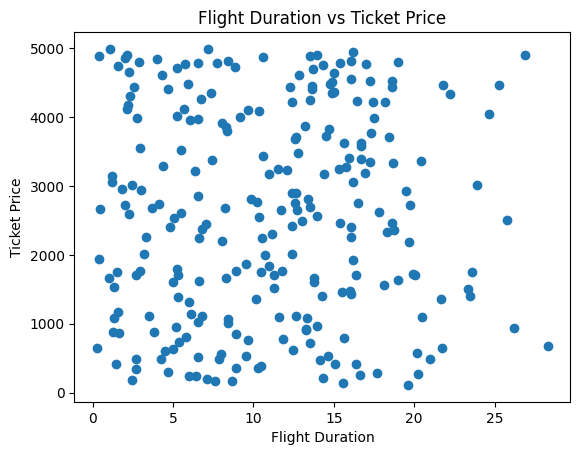

In [41]:
## Visualisation 1

plt.scatter( df['Flight_Duration_hr'], df['Ticket_Price'])
plt.xlabel('Flight Duration')
plt.ylabel('Ticket Price')
plt.title('Flight Duration vs Ticket Price')
plt.show()

<Axes: xlabel='Flight_Duration_hr', ylabel='Ticket_Price'>

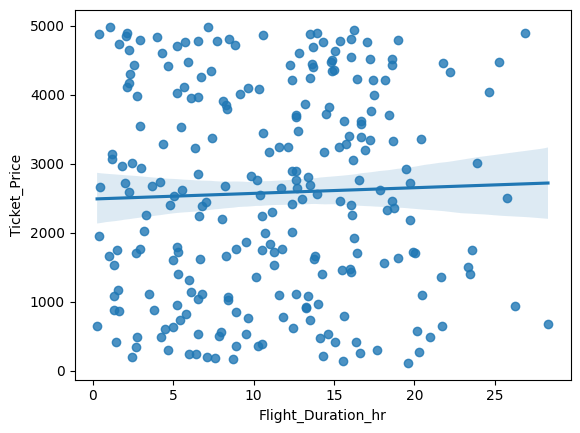

In [42]:
## Visualization 2 

sns.regplot( data = df, x = 'Flight_Duration_hr', y = 'Ticket_Price')

#### Average Flight Duration By Travel Class

In [43]:
Average_Flight_Duration_By_Travel_Class = df.groupby('Travel_Class', as_index= False)['Flight_Duration_hr'].mean().sort_values(by= 'Flight_Duration_hr', ascending= False).reset_index( drop = True).round(2).rename(columns = {'Flight_Duration_hr' : 'Average_Flight_Duration'})

print(Average_Flight_Duration_By_Travel_Class)

      Travel_Class  Average_Flight_Duration
0         Business                    11.53
1  Premium Economy                    11.07
2          Economy                    10.88
3            First                    10.68


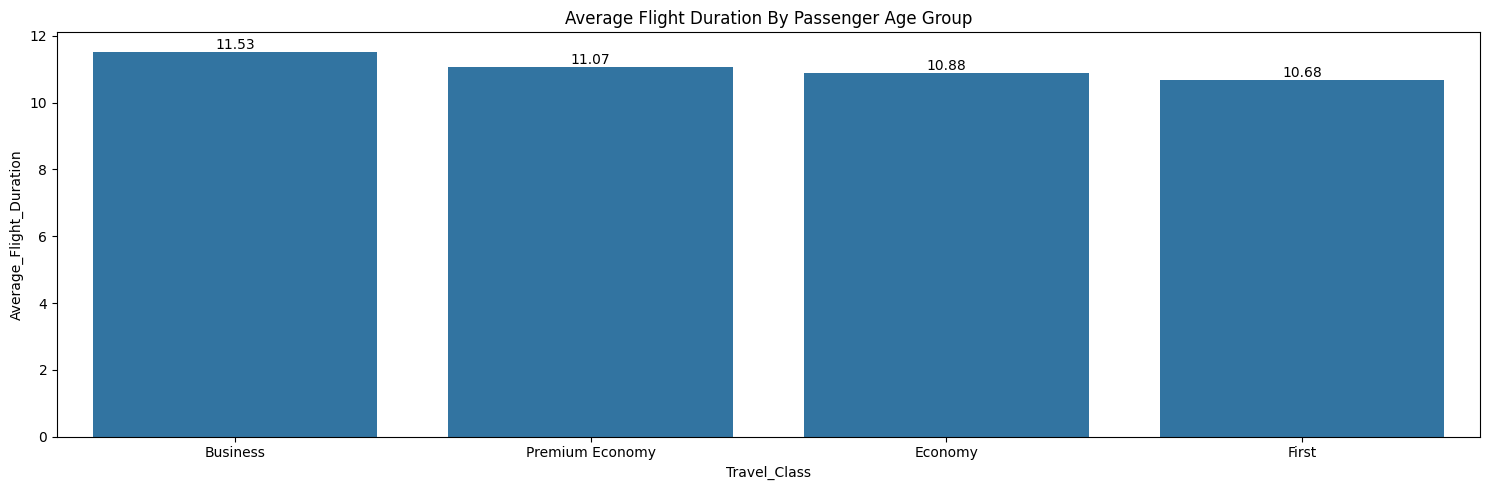

In [44]:
# Visualization 

plt.figure(figsize = ( 15, 5 ))

ax = sns.barplot( data = Average_Flight_Duration_By_Travel_Class, x = 'Travel_Class', y = 'Average_Flight_Duration' )

for i in ax.containers :
    ax.bar_label(i)

plt.title('Average Flight Duration By Passenger Age Group')
plt.xlabel('Travel_Class')
plt.ylabel('Average_Flight_Duration')
plt.tight_layout()
plt.show()

#### Average Revenue Per Booking

In [45]:
Average_Revenue_Per_Booking = (Total_Ticket_Price / Total_Bookings).round(2)

print(Average_Revenue_Per_Booking)

2578.26


In [46]:
## Test to verify if one row has one booking. If both the results are same then it means one row has one booking
# If one row equals one booking then average ticket price equals average revenue per booking
 
df['Booking_ID'].nunique(), len(df)

# hence we can remove the kpi - Averge_Ticket_Price as they both are giving same results

(250, 250)

#### Average Distance Per Flight

In [47]:
Average_Distance_Per_Flight = round((Total_Distance / Total_Bookings), 2)

print(Average_Distance_Per_Flight)

7556.95


#### Total Revenue Per Km

In [48]:
Total_Revenue_Per_Km = round((Total_Ticket_Price / Total_Distance), 2)

print(Total_Revenue_Per_Km)

0.34


#### Flight Duration & Variation By Airline

In [49]:
Average_Flight_Duration_And_Variation_By_Airline = df.groupby('Airline', as_index= False).agg(Average_Flight_Duration = ( 'Flight_Duration_hr' , 'mean'), Flight_Duration_Variation = ( 'Flight_Duration_hr' , lambda x : x.std(ddof = 0))).sort_values( by = ['Flight_Duration_Variation', 'Average_Flight_Duration'], ascending = [ False, False ]).reset_index( drop = True ).round(2)

print(Average_Flight_Duration_And_Variation_By_Airline)


      Airline  Average_Flight_Duration  Flight_Duration_Variation
0   Q Airways                    12.16                       7.26
1  L Airlines                    10.45                       6.57
2   B Airways                     9.88                       6.51
3  E Airlines                    12.02                       6.25
4       Air I                    12.99                       5.46
5  S Airlines                     9.43                       5.32


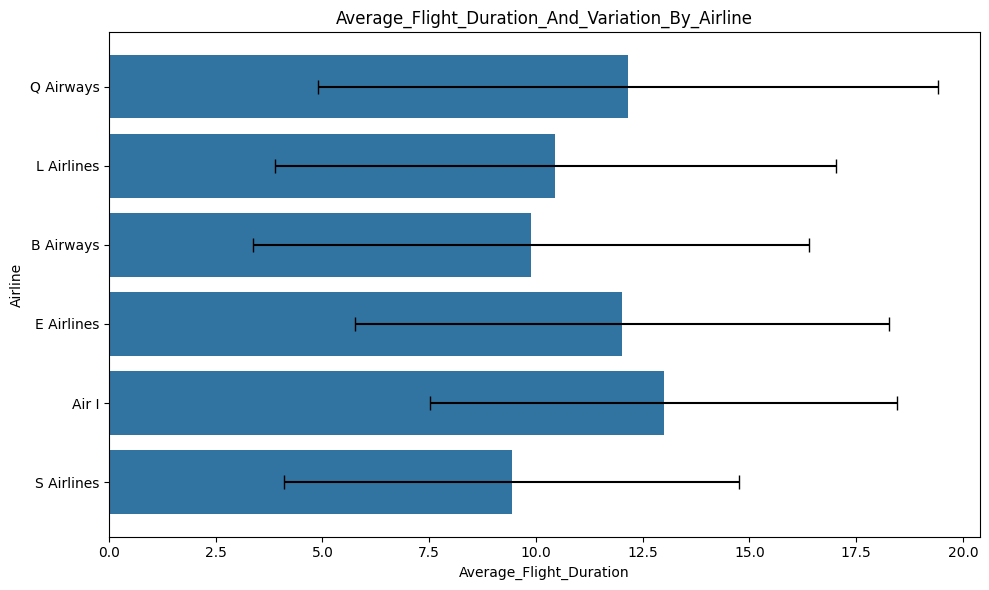

In [ ]:
## Visualisation

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=Average_Flight_Duration_And_Variation_By_Airline,
    x='Average_Flight_Duration',
    y='Airline',
    orient='h'
)

plt.errorbar(
    x=Average_Flight_Duration_And_Variation_By_Airline['Average_Flight_Duration'],
    y=range(len(Average_Flight_Duration_And_Variation_By_Airline)),
    xerr=Average_Flight_Duration_And_Variation_By_Airline['Flight_Duration_Variation'],
    fmt='none',
    c='black',
    capsize=5
)

plt.title('Average_Flight_Duration_And_Variation_By_Airline')
plt.xlabel('Average_Flight_Duration')
plt.ylabel('Airline')

plt.tight_layout()
plt.show()